In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import chaoticPackage as CC
import scipy.fft as fft
from scipy.signal import find_peaks as fp
import struct

In [2]:
tfiles = os.listdir("lower/")
files = ["lower/"+x for x in tfiles]
tfiles = os.listdir("lowmid/")
files += ["lowmid/"+x for x in tfiles]
tfiles = os.listdir("afterlower/")
files += ["afterlower/"+x for x in tfiles]
tfiles = os.listdir("mid/")[-350:]
files += ["mid/"+x for x in tfiles]
tfiles = os.listdir("upmid/")
files += ["upmid/"+x for x in tfiles]
tfiles = os.listdir("mid/")
files += ["mid/"+x for x in tfiles]
rvalues = np.arange(10.0,50.0,step=0.1)
rvalues = np.append(rvalues, np.arange(50.0,115.05,step=0.05))
rvalues = np.append(rvalues, np.arange(115.1,150.1,step=0.1))
rvalues = np.append(rvalues, np.arange(75.00,115.00,step=0.05))
rvalues = np.append(rvalues, np.arange(50.0,150.1,step=0.1))

print(len(files))
print(len(rvalues))

3852
3852


In [3]:
RV = np.array([])
DATA = np.array([])
for i in range(len(files)):
    temp = CC.getAmplitudes(files[i])
    RV = np.append(RV, np.ones(len(temp))*rvalues[i])
    DATA = np.append(DATA, temp)
    

In [4]:
CC.pack("test.bin",RV,DATA)

In [5]:
RVT,DATAT = CC.unpack("test.bin")

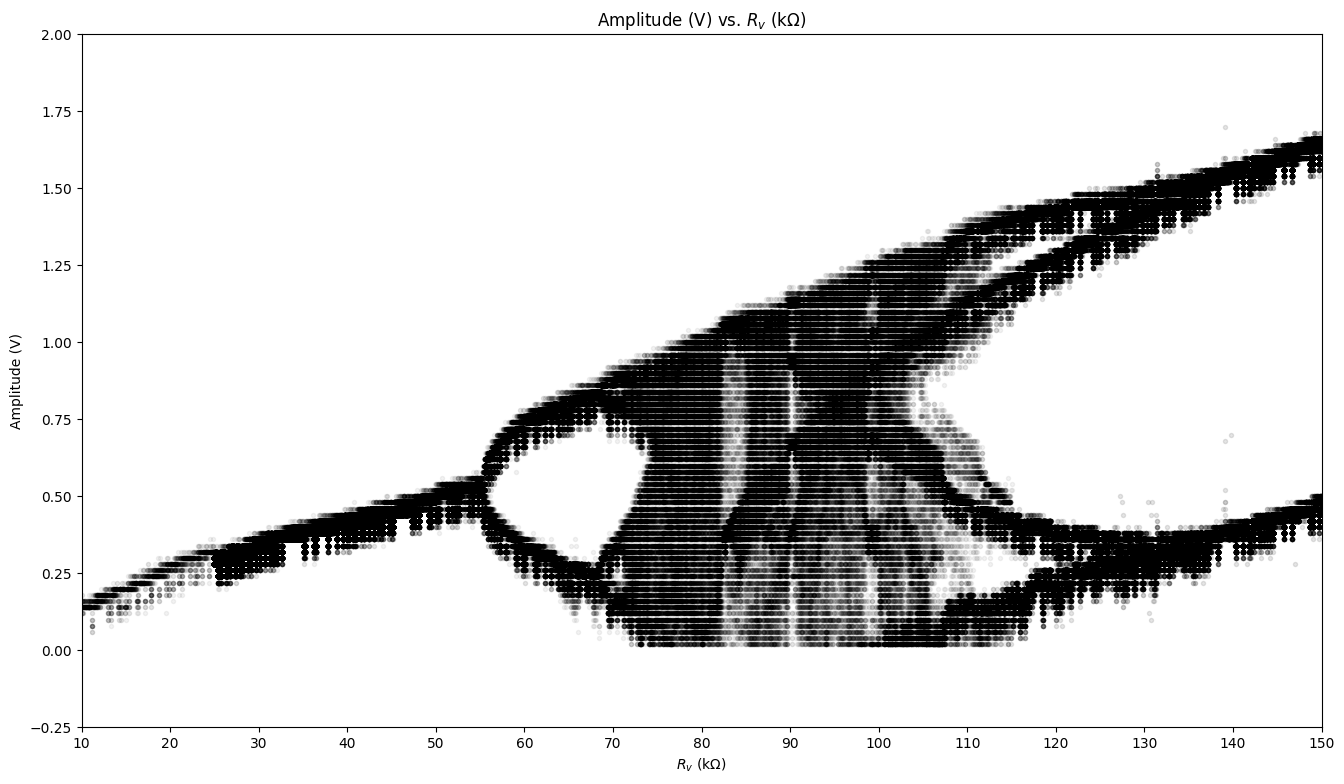

In [8]:
plt.figure(figsize=(16,9),dpi=100)
plt.plot(RVT,DATAT,'ko',markersize=3,alpha=0.05)
plt.ylabel(r"Amplitude (V)")
plt.xlabel(r"$R_v$ (k$\Omega$)")
plt.title(r"Amplitude (V) vs. $R_v$ (k$\Omega$)")
plt.ylim([-0.25,2])
plt.xticks(np.linspace(10.0,150.0,15))
plt.xlim([10,150])
plt.show()